In [4]:
%matplotlib inline

In [5]:
from pathlib import Path
import pickle
import json

PROJECT_ROOT = Path.cwd().parents[1]

RESULT_DIR = PROJECT_ROOT / "models" / "RNN" / "results"

history_path = RESULT_DIR / "rnn_training_history.pkl"
results_path = RESULT_DIR / "rnn_results.json"

with open(history_path, "rb") as f:
    history = pickle.load(f)

with open(results_path, "r") as f:
    rnn_results = json.load(f)

print("RNN experiment results loaded successfully.")
print()
print("Training history keys:")
print(history.keys())
print()
print("RNN test results:")
for key, value in rnn_results.items():
    print(f"{key}: {value}")

RNN experiment results loaded successfully.

Training history keys:
dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])

RNN test results:
model: Bidirectional RNN
accuracy: 0.7295238095238096
precision_weighted: 0.7344507934357337
recall_weighted: 0.7295238095238096
f1_weighted: 0.7278126521521932
roc_auc_weighted_ovr: 0.8702207265122653
confusion_matrix: [[158, 17, 11], [57, 131, 78], [39, 82, 477]]
class_mapping: {'0': 'Poor', '1': 'Average', '2': 'Good'}


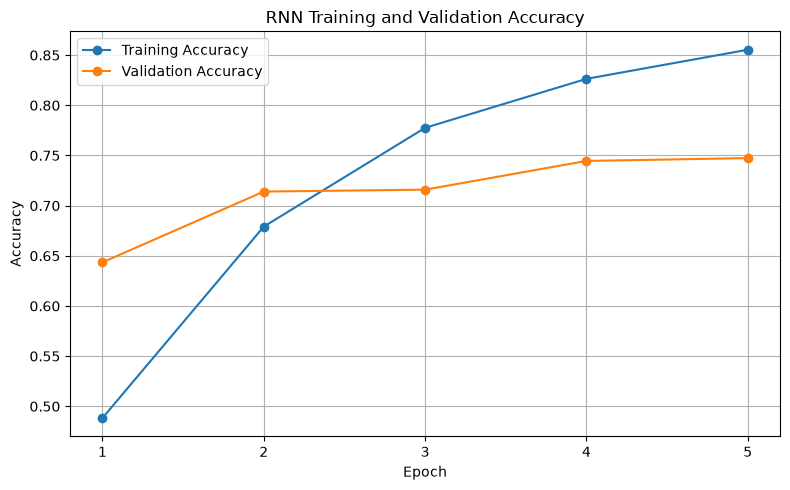

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    range(1, len(history["accuracy"]) + 1),
    history["accuracy"],
    label="Training Accuracy",
    marker="o"
)

ax.plot(
    range(1, len(history["val_accuracy"]) + 1),
    history["val_accuracy"],
    label="Validation Accuracy",
    marker="o"
)

ax.set_title("RNN Training and Validation Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_xticks(range(1, len(history["accuracy"]) + 1))
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

In [11]:
import matplotlib
import matplotlib.pyplot as plt

print("Matplotlib version:", matplotlib.__version__)
print("Backend:", matplotlib.get_backend())


Matplotlib version: 3.11.2
Backend: inline


In [12]:
print("Epoch | Train Accuracy | Validation Accuracy")
print("-" * 45)

for epoch, (train_acc, val_acc) in enumerate(
    zip(history["accuracy"], history["val_accuracy"]),
    start=1
):
    print(
        f"{epoch:5d} | "
        f"{train_acc:.4f}        | "
        f"{val_acc:.4f}"
    )

Epoch | Train Accuracy | Validation Accuracy
---------------------------------------------
    1 | 0.4883        | 0.6435
    2 | 0.6791        | 0.7140
    3 | 0.7775        | 0.7159
    4 | 0.8264        | 0.7445
    5 | 0.8554        | 0.7474


In [13]:
print("Epoch | Train Loss | Validation Loss")
print("-" * 40)

for epoch, (train_loss, val_loss) in enumerate(
    zip(history["loss"], history["val_loss"]),
    start=1
):
    print(
        f"{epoch:5d} | "
        f"{train_loss:.4f}     | "
        f"{val_loss:.4f}"
    )

Epoch | Train Loss | Validation Loss
----------------------------------------
    1 | 1.0231     | 0.7993
    2 | 0.7669     | 0.6458
    3 | 0.5292     | 0.6609
    4 | 0.3995     | 0.6938
    5 | 0.3325     | 0.7121


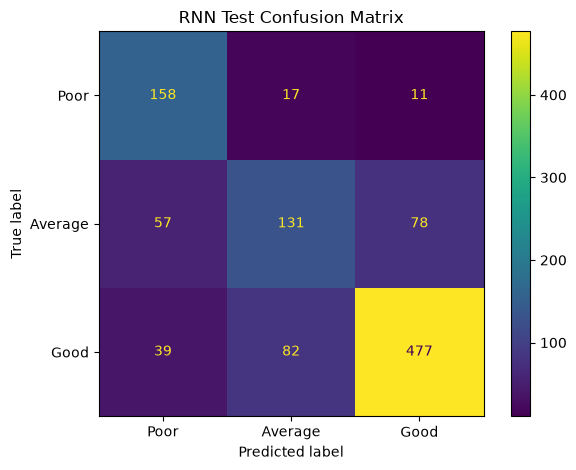

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

confusion_matrix = np.array(
    rnn_results["confusion_matrix"]
)

class_names = [
    rnn_results["class_mapping"]["0"],
    rnn_results["class_mapping"]["1"],
    rnn_results["class_mapping"]["2"]
]

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix,
    display_labels=class_names
)

disp.plot()

plt.title("RNN Test Confusion Matrix")
plt.tight_layout()
plt.show()

In [15]:
print("RNN Test Confusion Matrix")
print()
print("Rows = Actual Class")
print("Columns = Predicted Class")
print()
print("              Poor  Average  Good")
print(f"Poor          {confusion_matrix[0,0]:4d}  {confusion_matrix[0,1]:7d}  {confusion_matrix[0,2]:4d}")
print(f"Average       {confusion_matrix[1,0]:4d}  {confusion_matrix[1,1]:7d}  {confusion_matrix[1,2]:4d}")
print(f"Good          {confusion_matrix[2,0]:4d}  {confusion_matrix[2,1]:7d}  {confusion_matrix[2,2]:4d}")

RNN Test Confusion Matrix

Rows = Actual Class
Columns = Predicted Class

              Poor  Average  Good
Poor           158       17    11
Average         57      131    78
Good            39       82   477


In [16]:
from sklearn.metrics import classification_report

y_true = []

for actual_class, row in enumerate(confusion_matrix):
    for predicted_class, count in enumerate(row):
        y_true.extend([actual_class] * count)

y_pred = []

for actual_class, row in enumerate(confusion_matrix):
    for predicted_class, count in enumerate(row):
        y_pred.extend([predicted_class] * count)

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print("RNN Per-Class Test Metrics")
print()
print(report)

RNN Per-Class Test Metrics

              precision    recall  f1-score   support

        Poor     0.6220    0.8495    0.7182       186
     Average     0.5696    0.4925    0.5282       266
        Good     0.8428    0.7977    0.8196       598

    accuracy                         0.7295      1050
   macro avg     0.6781    0.7132    0.6887      1050
weighted avg     0.7345    0.7295    0.7278      1050



## RNN Experiment Analysis

The Bidirectional RNN model was trained for a maximum of 20 epochs with early stopping based on validation loss. Training stopped after 5 epochs, and the weights from epoch 2 were restored because epoch 2 produced the lowest validation loss (0.6458).

Training accuracy increased from 0.4883 at epoch 1 to 0.8554 at epoch 5, while validation accuracy increased from 0.6435 to 0.7474. Training loss decreased continuously, whereas validation loss reached its minimum at epoch 2 and increased afterwards. This indicates increasing divergence between training and validation performance after the second epoch.

On the held-out test set of 1,050 reviews, the model achieved 72.95% accuracy, 73.45% weighted precision, 72.95% weighted recall, 72.78% weighted F1-score, and 0.8702 weighted one-vs-rest ROC-AUC.

Class-level performance was uneven. The Good class achieved an F1-score of 0.8196, while the Poor class achieved an F1-score of 0.7182. The Average class had the lowest F1-score at 0.5282. The confusion matrix showed considerable confusion between Average and Good reviews, indicating that these two rating groups were more difficult for the model to distinguish.